# Demo 08: Forward Operator G and Inversion with pygeoinf

This notebook is a **pygeoinf-powered** version of Demo 07.
It builds the same discretized forward operator $G$ for a 1-D seismic
travel-time inverse problem, but delegates all linear-operator algebra and
inversion to **[pygeoinf](https://github.com/username/pygeoinf)** — an abstract
Hilbert-space framework designed for geophysical inverse problems.

**Key differences from Demo 07**

| Aspect | Demo 07 (manual numpy) | Demo 08 (pygeoinf) |
|--------|------------------------|--------------------|
| Model space | plain `np.ndarray`, inner product handled manually | `MassWeightedHilbertSpace` — inner product is $M$-weighted |
| Adjoint | `G* = M⁻¹ Gᵀ` coded by hand | automatic via Riesz map of `MassWeightedHilbertSpace` |
| Inversion | hand-rolled data-space solver | `LinearMinimumNormInversion` / `LinearLeastSquaresInversion` |
| Data noise | manual Gaussian noise | `GaussianMeasure` on `EuclideanSpace` |

**Workflow**

1. Load PREM (M1) and build a spherical shell mesh.
2. Define 5 events × 5 stations (P-waves only).
3. Compute discretized sensitivity kernels $\tilde K_{ij} = -L_{ij}/v_j^2$.
4. Build the pygeoinf operator $G : \mathcal{M} \to \mathcal{D}$ with
   $\mathcal{M} = $ `MassWeightedHilbertSpace` and $\mathcal{D} = $ `EuclideanSpace`.
5. Let pygeoinf derive $G^* = M^{-1}G^T$ automatically from the Riesz map.
6. Generate synthetic noisy data via a `GaussianMeasure` data-error model.
7. Invert with `LinearMinimumNormInversion` (exact, $\lambda = 0$) and
   `LinearLeastSquaresInversion` (Tikhonov $\lambda > 0$).
8. Plot kernel coverage, L-curve, and model recovery.

## 1 · Imports and Setup

In [2]:
import sys, os
# ── SensRay ──────────────────────────────────────────────────────────────
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
# ── pygeoinf ─────────────────────────────────────────────────────────────
sys.path.insert(0, '/disks/data/PhD/Inferences/pygeoinf')

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

# SensRay
from sensray import PlanetModel

# pygeoinf — spaces, operators, inference
import pygeoinf as pg
from pygeoinf import (
    EuclideanSpace,
    MassWeightedHilbertSpace,
    LinearOperator,
    GaussianMeasure,
    LinearForwardProblem,
    LinearMinimumNormInversion,
    LinearLeastSquaresInversion,
    LUSolver,
)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print('All imports OK')
version = getattr(pg, '__version__', '(no __version__)')
print(f'pygeoinf version: {version}')


All imports OK
pygeoinf version: (no __version__)


## 2 · Load Planet Model and Build Spherical Mesh

In [3]:
model = PlanetModel.from_standard_model('M1')
print(f'Model  : {model.name}')
print(f'Radius : {model.radius:.1f} km')

DR = 20.0   # km — radial shell spacing
mesh_radii = list(np.arange(0.0, model.radius, DR))
if mesh_radii[-1] < model.radius:
    mesh_radii.append(float(model.radius))

mesh = model.create_mesh('spherical', radii=mesh_radii)
mesh.populate_properties(['vp'])

N_CELLS       = mesh.mesh.n_cells
shell_radii   = np.array(mesh.mesh.radii, dtype=float)
shell_centres = 0.5 * (shell_radii[:-1] + shell_radii[1:])
shell_depths  = model.radius - shell_centres
vp_ref        = np.array(mesh.mesh.cell_data['vp'], dtype=float)

print(f'\ndr = {DR} km  →  {N_CELLS} shells')
print(f'vp range  : {vp_ref.min():.2f} – {vp_ref.max():.2f} km/s')

Model  : M1
Radius : 1737.1 km
Generated spherical mesh: 87 layers, 88 boundaries
Populated properties: ['vp']

dr = 20.0 km  →  87 shells
vp range  : 4.56 – 8.24 km/s


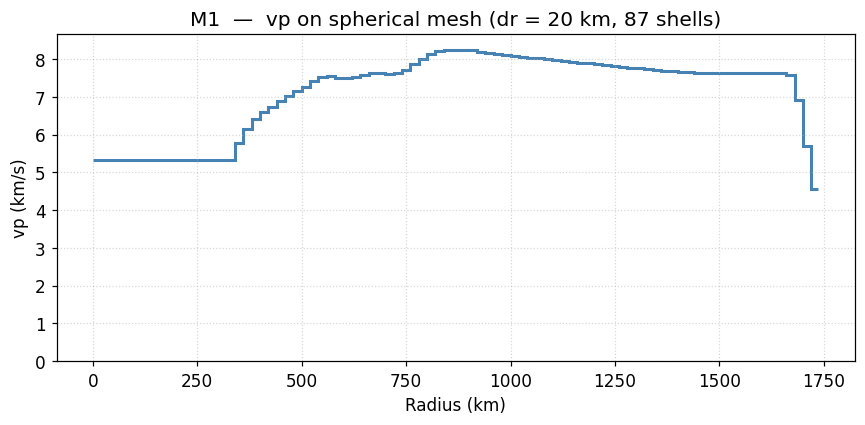

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.stairs(vp_ref, shell_radii, baseline=None, color='steelblue', lw=2)
ax.set_xlabel('Radius (km)')
ax.set_ylabel('vp (km/s)')
ax.set_title(f'{model.name}  —  vp on spherical mesh (dr = {DR:.0f} km, {N_CELLS} shells)')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 3 · Define 5 Events and 5 Stations

In [5]:
events = {
    'E1': {'depth_km':   10.0},
    'E2': {'depth_km':  100.0},
    'E3': {'depth_km':  300.0},
    'E4': {'depth_km':  600.0},
    'E5': {'depth_km': 1000.0},
}

stations = {
    'S1': {'dist_deg':  20.0},
    'S2': {'dist_deg':  45.0},
    'S3': {'dist_deg':  90.0},
    'S4': {'dist_deg': 120.0},
    'S5': {'dist_deg': 150.0},
}

pairs = [(e, s) for e in events for s in stations]
print(f'Source–receiver pairs ({len(pairs)} total):')
for ev, st in pairs:
    print(f'  {ev}–{st}   depth={events[ev]["depth_km"]:6.0f} km    Δ={stations[st]["dist_deg"]}°')

Source–receiver pairs (25 total):
  E1–S1   depth=    10 km    Δ=20.0°
  E1–S2   depth=    10 km    Δ=45.0°
  E1–S3   depth=    10 km    Δ=90.0°
  E1–S4   depth=    10 km    Δ=120.0°
  E1–S5   depth=    10 km    Δ=150.0°
  E2–S1   depth=   100 km    Δ=20.0°
  E2–S2   depth=   100 km    Δ=45.0°
  E2–S3   depth=   100 km    Δ=90.0°
  E2–S4   depth=   100 km    Δ=120.0°
  E2–S5   depth=   100 km    Δ=150.0°
  E3–S1   depth=   300 km    Δ=20.0°
  E3–S2   depth=   300 km    Δ=45.0°
  E3–S3   depth=   300 km    Δ=90.0°
  E3–S4   depth=   300 km    Δ=120.0°
  E3–S5   depth=   300 km    Δ=150.0°
  E4–S1   depth=   600 km    Δ=20.0°
  E4–S2   depth=   600 km    Δ=45.0°
  E4–S3   depth=   600 km    Δ=90.0°
  E4–S4   depth=   600 km    Δ=120.0°
  E4–S5   depth=   600 km    Δ=150.0°
  E5–S1   depth=  1000 km    Δ=20.0°
  E5–S2   depth=  1000 km    Δ=45.0°
  E5–S3   depth=  1000 km    Δ=90.0°
  E5–S4   depth=  1000 km    Δ=120.0°
  E5–S5   depth=  1000 km    Δ=150.0°


## 4 · Compute P-wave Ray Paths with TauP

In [6]:
print('Building TauP model (first call may take ~10 s) …')
taup = model.taupy_model
print('TauP ready.\n')

rays_catalog = {}
for ev_name, evt in events.items():
    for st_name, sta in stations.items():
        arrivals = taup.get_ray_paths(
            source_depth_in_km=evt['depth_km'],
            distance_in_degree=sta['dist_deg'],
            phase_list=['P'],
        )
        if arrivals:
            arr = arrivals[0]
            rays_catalog[(ev_name, st_name)] = arr
            print(f'  {ev_name}–{st_name}  Δ={sta["dist_deg"]:5.1f}°  '
                  f'depth={evt["depth_km"]:.0f} km  '
                  f't={arr.time:.2f} s  path_pts={len(arr.path)}')
        else:
            print(f'  {ev_name}–{st_name}: no P arrival found!')

print(f'\nTotal rays: {len(rays_catalog)}')

Building TauP model (first call may take ~10 s) …
Building obspy.taup model for '/disks/data/PhD/masters/SensRay/sensray/models/M1.nd' ...
filename = /disks/data/PhD/masters/SensRay/sensray/models/M1.nd
Done reading velocity model.
Radius of model . is 1737.1
Using parameters provided in TauP_config.ini (or defaults if not) to call SlownessModel...
Parameters are:
taup.create.min_delta_p = 0.1 sec / radian
taup.create.max_delta_p = 11.0 sec / radian
taup.create.max_depth_interval = 115.0 kilometers
taup.create.max_range_interval = 0.04363323129985824 degrees
taup.create.max_interp_error = 0.05 seconds
taup.create.allow_inner_core_s = True
Slow model  643 P layers,747 S layers
Done calculating Tau branches.
Done Saving /tmp/M1.npz
Method run is done, but not necessarily successful.
TauP ready.

  E1–S1  Δ= 20.0°  depth=10 km  t=88.33 s  path_pts=238
  E1–S2  Δ= 45.0°  depth=10 km  t=181.14 s  path_pts=276
  E1–S3  Δ= 90.0°  depth=10 km  t=321.80 s  path_pts=516
  E1–S4  Δ=120.0°  depth=

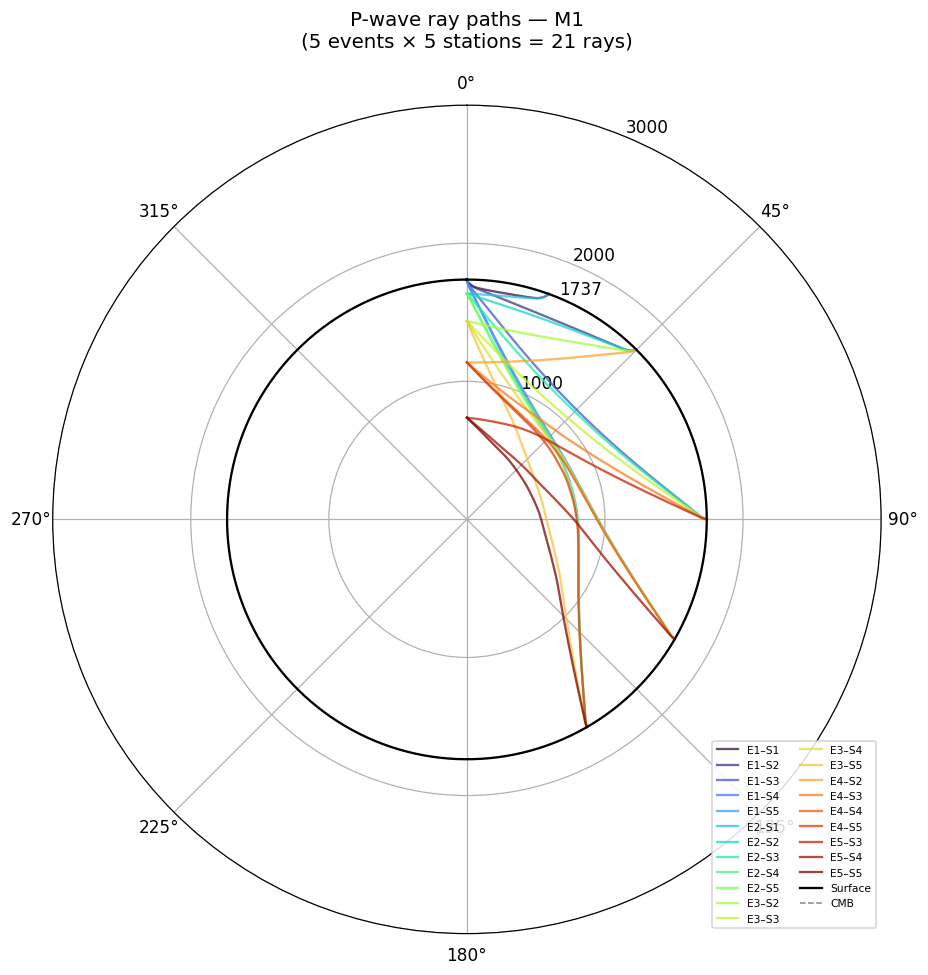

In [7]:
ray_keys   = list(rays_catalog.keys())
n_rays_plt = len(ray_keys)
cmap_r     = plt.cm.tab20 if n_rays_plt <= 20 else plt.cm.turbo
ray_colors = {key: cmap_r(i / max(n_rays_plt - 1, 1)) for i, key in enumerate(ray_keys)}

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

for (ev_name, st_name), arr in rays_catalog.items():
    theta  = arr.path['dist']
    radius = model.radius - arr.path['depth']
    ax.plot(theta, radius, lw=1.5, color=ray_colors[(ev_name, st_name)], alpha=0.75,
            label=f'{ev_name}–{st_name}')

theta_full = np.linspace(0, 2 * np.pi, 360)
ax.plot(theta_full, np.full_like(theta_full, model.radius), 'k-', lw=1.5, label='Surface')
ax.plot(theta_full, np.full_like(theta_full, 3480.0), color='#888', lw=1.0, ls='--', label='CMB')

ax.set_rmax(model.radius * 1.05)
ax.set_rmin(0)
ax.set_rticks([1000, 2000, 3000, int(model.radius)])
ax.set_title(f'P-wave ray paths — {model.name}\n({len(events)} events × {len(stations)} stations = {n_rays_plt} rays)',
             fontsize=13, pad=18)
ax.legend(loc='lower right', fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.show()

## 5 · Compute Discretized Sensitivity Kernels

For each ray $i$ through shell $j$:

$$\tilde{K}_{ij} = -\frac{L_{ij}}{v_j^2}, \qquad \text{units: s km}^{-1}$$

where $L_{ij}$ is the chord length through shell $j$ and $v_j$ is the
shell-averaged P-wave speed.

In [8]:
ray_labels = []
K_list     = []
L_list     = []

for (ev_name, st_name), arr in rays_catalog.items():
    label = f'{ev_name}–{st_name}'
    ray_labels.append(label)

    K_i = mesh.compute_sensitivity_kernel(arr, 'vp', normalize=False,
                                          attach_name=f'K_{ev_name}_{st_name}')
    L_i = mesh.compute_ray_lengths(arr)
    K_list.append(K_i)
    L_list.append(L_i)

    print(f'  {label:8s}  path = {L_i.sum():7.1f} km   max|K| = {np.abs(K_i).max():.4e} s/km')

K_tilde = np.array(K_list, dtype=float)   # shape (n_obs, N_CELLS)
print(f'\nK_tilde shape: {K_tilde.shape}')

Stored sensitivity kernel as cell data: 'K_E1_S1'
  E1–S1     path =   624.7 km   max|K| = 7.6592e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S2'
  E1–S2     path =  1337.1 km   max|K| = 5.8134e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S3'
  E1–S3     path =  2462.1 km   max|K| = 5.7017e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S4'
  E1–S4     path =  3003.8 km   max|K| = 3.6752e+00 s/km
Stored sensitivity kernel as cell data: 'K_E1_S5'
  E1–S5     path =  3422.9 km   max|K| = 5.3989e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S1'
  E2–S1     path =   602.8 km   max|K| = 4.8305e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S2'
  E2–S2     path =  1300.2 km   max|K| = 5.8343e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S3'
  E2–S3     path =  2396.5 km   max|K| = 5.7332e+00 s/km
Stored sensitivity kernel as cell data: 'K_E2_S4'
  E2–S4     path =  2925.0 km   max|K| = 4.6485e+00 s/km
Stored sensitivity kernel as cell dat

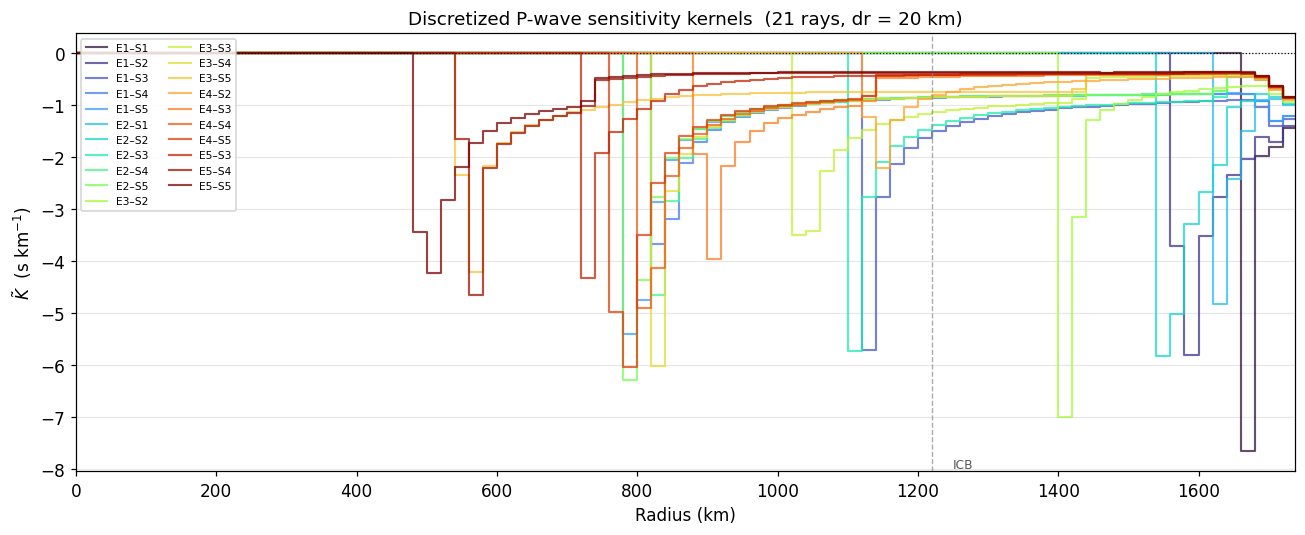

In [9]:
n_k    = len(K_list)
cmap_k = plt.cm.tab20 if n_k <= 20 else plt.cm.turbo
colors = [cmap_k(i / max(n_k - 1, 1)) for i in range(n_k)]

fig, ax = plt.subplots(figsize=(12, 5))
for label, K_i, color in zip(ray_labels, K_list, colors):
    r_plot, k_plot = [], []
    for j in range(len(K_i)):
        r_plot += [shell_radii[j], shell_radii[j+1]]
        k_plot += [K_i[j], K_i[j]]
    ax.plot(r_plot, k_plot, lw=1.4, color=color, alpha=0.75, label=label)

ax.axhline(0, color='k', lw=0.8, ls=':')
for r_disc, name in [(3480.0, 'CMB'), (1220.0, 'ICB')]:
    if shell_radii[0] < r_disc < shell_radii[-1]:
        ax.axvline(r_disc, color='#888', lw=0.9, ls='--', alpha=0.7)
        ax.text(r_disc + 30, ax.get_ylim()[0], name, fontsize=8, color='#555', va='bottom')
ax.set_xlim(0, model.radius)
ax.set_xlabel('Radius (km)', fontsize=11)
ax.set_ylabel(r'$\tilde{K}$  (s km$^{-1}$)', fontsize=11)
ax.set_title(f'Discretized P-wave sensitivity kernels  ({n_k} rays, dr = {DR:.0f} km)', fontsize=12)
ax.legend(fontsize=7, loc='upper left', framealpha=0.85, ncol=max(1, n_k // 10))
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · Build pygeoinf Spaces and the Forward Operator

### Why the model space must be mass-weighted

SensRay uses **indicator basis functions** $\phi_j = \mathbf{1}_{V_j}$.  Their
$L^2(\mathrm{d}V)$ Gram matrix is

$$\langle \phi_i, \phi_j \rangle = V_j \delta_{ij} \implies
M = \mathrm{diag}(V_1, \ldots, V_N), \quad V_j = \tfrac{4\pi}{3}(r_{j+1}^3 - r_j^3)$$

The physically correct model-space inner product is therefore
$\langle u, v \rangle_M = u^T M v$, represented in pygeoinf as a
`MassWeightedHilbertSpace`.

### Galerkin representation and the adjoint

The raw kernel matrix $\tilde K \in \mathbb{R}^{N_\mathrm{obs}\times N}$ with entries
$\tilde K_{ij} = -L_{ij}/v_j^2$ is the **standard (non-Galerkin) matrix representation**:
it maps coefficient vectors $\mathbf{m}$ directly to data vectors $(G\mathbf{m})_i = \sum_j \tilde K_{ij} m_j$.

When pygeoinf constructs `LinearOperator.from_matrix(model_space, data_space, G_mat, galerkin=False)`, 
it uses the Riesz map of `MassWeightedHilbertSpace` to derive the adjoint automatically:

$$G^*(y) = R_{\mathcal{M}}^{-1}\bigl(G^T y\bigr) = M^{-1} G^T y$$

because the inverse Riesz map of $M$-weighted space is $R_M^{-1}(\xi) = M^{-1}\xi$.

No manual adjoint coding is needed — the inner product geometry is baked into the space.

The **Galerkin representation** (`galerkin=True`) is used when the matrix was already
assembled as $[G]^\mathrm{Gal}_{ij} = \langle G\phi_j, e_i^\star \rangle_{\mathcal{D}^*}$,
i.e. the matrix rows are already dual-space objects.  In our case the data space is
Euclidean so the Galerkin and standard forms coincide, and `galerkin=False` is correct.
If the data space were also mass-weighted the two forms would differ.

In [10]:
# ── Spaces ────────────────────────────────────────────────────────────────
N      = N_CELLS
n_obs  = len(ray_labels)

# Underlying Euclidean space for model (coefficient space)
euclidean_model = EuclideanSpace(N)

# Data space: standard Euclidean (travel-time perturbations in seconds)
data_space = EuclideanSpace(n_obs)

# ── Mass matrix from shell volumes ────────────────────────────────────────
V          = mesh.cell_volumes                # shape (N,) in km³
M_diag     = V
M_inv_diag = 1.0 / V

# Build sparse diagonal operators (efficient for large N)
M_sparse     = sp.dia_array(sp.diags(M_diag))
M_inv_sparse = sp.dia_array(sp.diags(M_inv_diag))

# self_adjoint_from_matrix always uses galerkin=True internally, which is
# correct for a symmetric positive-definite operator.
mass_op     = LinearOperator.self_adjoint_from_matrix(euclidean_model, M_sparse)
inv_mass_op = LinearOperator.self_adjoint_from_matrix(euclidean_model, M_inv_sparse)

# The M-weighted model space: inner product <u,v>_M = u^T M v
model_space = MassWeightedHilbertSpace(euclidean_model, mass_op, inv_mass_op)

print(f'model_space : MassWeightedHilbertSpace  dim = {model_space.dim}')
print(f'data_space  : EuclideanSpace             dim = {data_space.dim}')
print(f'\nMass matrix:')
print(f'  min V = {V.min():.3e} km³   max V = {V.max():.3e} km³')
print(f'  ratio = {V.max()/V.min():.0f}×  — shells differ enormously in volume')

model_space : MassWeightedHilbertSpace  dim = 87
data_space  : EuclideanSpace             dim = 21

Mass matrix:
  min V = 3.351e+04 km³   max V = 7.349e+08 km³
  ratio = 21931×  — shells differ enormously in volume


In [11]:
# ── Forward operator G : model_space → data_space ─────────────────────────
G_mat   = K_tilde.copy()   # shape (n_obs, N)
fwd_op  = LinearOperator.from_matrix(model_space, data_space, G_mat, galerkin=False)

print('Forward operator G:')
print(f'  domain   : {fwd_op.domain}')
print(f'  codomain : {fwd_op.codomain}')

# ── Verify adjoint is G* = M^{-1} G^T ────────────────────────────────────
rng           = np.random.default_rng(seed=0)
y_test        = rng.standard_normal(n_obs)
adj_pygeoinf  = fwd_op.adjoint(y_test)        # pygeoinf: M^{-1} G^T y
adj_manual    = M_inv_diag * (G_mat.T @ y_test)  # manual formula

print(f'\nAdjoint verification (random y):')
print(f'  ||G*(y) pygeoinf - M⁻¹Gᵀy manual|| = {np.linalg.norm(adj_pygeoinf - adj_manual):.2e}')

# ── Verify inner product ──────────────────────────────────────────────────
x_test = rng.standard_normal(N)
ip_pg  = model_space.inner_product(x_test, x_test)
ip_man = x_test @ (M_diag * x_test)
print(f'  ||<x,x>_M pygeoinf - xᵀMx manual|| = {abs(ip_pg - ip_man):.2e}')

Forward operator G:
  domain   : <pygeoinf.hilbert_space.MassWeightedHilbertSpace object at 0x7f622cbb0d10>
  codomain : <pygeoinf.hilbert_space.EuclideanSpace object at 0x7f622c9b7190>

Adjoint verification (random y):
  ||G*(y) pygeoinf - M⁻¹Gᵀy manual|| = 0.00e+00
  ||<x,x>_M pygeoinf - xᵀMx manual|| = 0.00e+00


## 7 · Generate Synthetic Data

A known velocity perturbation $\mathbf{m}_\mathrm{true}$ (Gaussian anomaly centred
at mid-mantle) is used to produce noise-free data $d_\mathrm{clean} = G\,\mathbf{m}_\mathrm{true}$.

Instrument/measurement noise is modelled as an isotropic Gaussian
`GaussianMeasure` on the `EuclideanSpace` data space, matching 1 % of the peak
clean signal.  This measure is attached to the `LinearForwardProblem` so that
all inversion methods automatically use the correct noise statistics.

In [12]:
# ── True model: Gaussian anomaly at mid-mantle ─────────────────────────────
r0_anomaly = model.radius - 1500.0   # centre radius (km)
sigma_r    = 800.0
m_true     = 0.3 * np.exp(-0.5 * ((shell_centres - r0_anomaly) / sigma_r) ** 2)

d_clean = fwd_op(m_true)

# ── Data error model using GaussianMeasure ─────────────────────────────────
noise_std          = 0.01 * np.abs(d_clean).max()
data_error_measure = GaussianMeasure.from_standard_deviation(data_space, noise_std)

# ── Noisy data (one realisation) ───────────────────────────────────────────
rng     = np.random.default_rng(seed=42)
noise   = rng.normal(0, noise_std, size=n_obs)
d_noisy = d_clean + noise

print(f'True model m_true:')
print(f'  peak  : {m_true.max():.3f} km/s  at r = {shell_centres[np.argmax(m_true)]:.0f} km')
print(f'  ||m||_M  : {model_space.norm(m_true):.4e}  (correct physical norm)')
print(f'  ||m||_2  : {np.linalg.norm(m_true):.4f}  (coefficient norm, for reference only)')
print(f'  noise σ  : {noise_std:.4e} s  ({noise_std*1e3:.4f} ms)')
print(f'\nSynthetic data d = G m_true + noise:')
for label, dt, n in zip(ray_labels, d_noisy, noise):
    print(f'  {label:8s}  δt = {dt*1e3:9.4f} ms  (noise = {n*1e3:.4f} ms)')

True model m_true:
  peak  : 0.300 km/s  at r = 230 km
  ||m||_M  : 2.1322e+04  (correct physical norm)
  ||m||_2  : 2.0498  (coefficient norm, for reference only)
  noise σ  : 1.0042e-01 s  (100.4221 ms)

Synthetic data d = G m_true + noise:
  E1–S1     δt = -721.0811 ms  (noise = 30.6003 ms)
  E1–S2     δt = -1755.3324 ms  (noise = -104.4374 ms)
  E1–S3     δt = -4772.2200 ms  (noise = 75.3619 ms)
  E1–S4     δt = -7258.3704 ms  (noise = 94.4535 ms)
  E1–S5     δt = -9170.6798 ms  (noise = -195.9270 ms)
  E2–S1     δt = -846.3038 ms  (noise = -130.7676 ms)
  E2–S2     δt = -1640.4871 ms  (noise = 12.8380 ms)
  E2–S3     δt = -4908.4884 ms  (noise = -31.7577 ms)
  E2–S4     δt = -7301.3735 ms  (noise = -1.6872 ms)
  E2–S5     δt = -9004.8083 ms  (noise = -85.6645 ms)
  E3–S2     δt = -1859.5302 ms  (noise = 88.3110 ms)
  E3–S3     δt = -4995.1598 ms  (noise = 78.1075 ms)
  E3–S4     δt = -7191.5554 ms  (noise = 6.6309 ms)
  E3–S5     δt = -9929.0094 ms  (noise = 113.1999 ms)
  E4–S2  

## 8 · Set Up the Linear Forward Problem

A `LinearForwardProblem` bundles the forward operator and the data error
measure.  All pygeoinf inversion classes accept this object — they use the
data error automatically when computing regularised normals and chi-squared
tests.

In [13]:
fp = LinearForwardProblem(fwd_op, data_error_measure=data_error_measure)

print('LinearForwardProblem created:')
print(f'  model space : dim = {fp.model_space.dim},  type = {type(fp.model_space).__name__}')
print(f'  data space  : dim = {fp.data_space.dim},  type = {type(fp.data_space).__name__}')
print(f'  data error  : σ = {noise_std:.3e} s  (isotropic Gaussian)')

# Rank of G
_, S_vals, _ = np.linalg.svd(G_mat, full_matrices=False)
rank_G = np.linalg.matrix_rank(G_mat)
print(f'\nForward operator G:')
print(f'  shape   : {G_mat.shape}  ( {n_obs} obs × {N} cells )')
print(f'  rank    : {rank_G}  (null-space dim = {N - rank_G})')
print(f'  cond(G) : {S_vals[0]/S_vals[-1]:.2e}')
print(f'  σ values: {np.round(S_vals, 4)}')

LinearForwardProblem created:
  model space : dim = 87,  type = MassWeightedHilbertSpace
  data space  : dim = 21,  type = EuclideanSpace
  data error  : σ = 1.004e-01 s  (isotropic Gaussian)

Forward operator G:
  shape   : (21, 87)  ( 21 obs × 87 cells )
  rank    : 21  (null-space dim = 66)
  cond(G) : 1.15e+02
  σ values: [25.0674 13.3465 10.9494 10.2242  8.9855  8.0476  7.5615  5.7423  5.5117
  5.2318  4.9829  4.6762  4.5933  4.2623  4.2183  3.3377  1.5688  1.4299
  0.8379  0.6178  0.2185]


## 9 · Inversion

### 9a · Exact minimum M-norm solution ($\lambda = 0$)

`LinearMinimumNormInversion` without a data error measure solves the **data-space
normal equations** exactly:

$$(G G^*)\boldsymbol{\alpha} = \mathbf{d}, \qquad \hat{\mathbf{m}} = G^*\boldsymbol{\alpha}$$

Because `fwd_op.adjoint = G* = M^{-1}G^T`, this expands to

$$\hat{\mathbf{m}} = M^{-1}G^T(G M^{-1} G^T)^{-1}\mathbf{d}$$

which is the smallest-$\|\cdot\|_M$ solution — all computed internally by
pygeoinf.

### 9b · Regularised solution ($\lambda > 0$)

`LinearLeastSquaresInversion` with damping $\alpha$ minimises

$$J(\mathbf{m}) = \|G\mathbf{m} - \mathbf{d}\|_{C_e^{-1}}^2 + \alpha^2\|\mathbf{m}\|_M^2$$

The model-space normal equations are

$$(G^T C_e^{-1} G + \alpha^2 M)\hat{\mathbf{m}} = G^T C_e^{-1}\mathbf{d}$$

where $C_e = \sigma^2 I$ is the data error covariance.  The $\alpha^2 M$ term is
the correct regulariser in the M-weighted norm — **not** plain $\alpha^2 I$.

In [15]:
solver = LUSolver()

# ── 9a: Exact minimum M-norm (no regularisation) ──────────────────────────
# Build a forward problem WITHOUT data error measure so that pygeoinf uses
# the pure min-norm formula (not the discrepancy principle).
fp_no_error = LinearForwardProblem(fwd_op)
mn_inv   = LinearMinimumNormInversion(fp_no_error)
mn_op    = mn_inv.minimum_norm_operator(solver)
m_hat_0  = mn_op(d_noisy)

print(f'λ = 0  (exact min M-norm):')
print(f'  data misfit  ||G m̂ - d||₂  = {np.linalg.norm(G_mat @ m_hat_0 - d_noisy):.4e}')
print(f'  model norm   ||m̂||_M       = {model_space.norm(m_hat_0):.4e}')
print()

# ── 9b: Tikhonov for a range of dampings ──────────────────────────────────
# fp (with data error) makes the normal operator use C_e^{-1} weighting.
# Damping=0 would make the normal equations singular; use min-norm for λ=0.
ls_inv = LinearLeastSquaresInversion(fp)

dampings    = [1e-10, 1e-7, 1e-4, 1.0]
damp_labels = [r'$\alpha=10^{-10}$', r'$\alpha=10^{-7}$',
               r'$\alpha=10^{-4}$', r'$\alpha=1$']

inv_results = []
for damp, dlabel in zip(dampings, damp_labels):
    ls_op  = ls_inv.least_squares_operator(damp, solver)
    m_hat  = ls_op(d_noisy)

    misfit = np.linalg.norm(G_mat @ m_hat - d_noisy)
    mnorm  = model_space.norm(m_hat)
    cnorm  = np.linalg.norm(m_hat)

    inv_results.append({
        'damp': damp, 'label': dlabel,
        'm_hat': m_hat,
        'misfit': misfit, 'mnorm': mnorm, 'cnorm': cnorm,
    })
    print(f'  α={damp:.0e}  misfit={misfit:.4e}  ||m||_M={mnorm:.4e}  ||m||_2={cnorm:.4e}')


λ = 0  (exact min M-norm):
  data misfit  ||G m̂ - d||₂  = 1.5391e-13
  model norm   ||m̂||_M       = 2.2659e+04

  α=1e-10  misfit=1.0259e-03  ||m||_M=2.2613e+04  ||m||_2=1.4872e+00
  α=1e-07  misfit=1.1517e-01  ||m||_M=1.9598e+04  ||m||_2=1.4256e+00
  α=1e-04  misfit=8.8305e+00  ||m||_M=1.2947e+04  ||m||_2=9.9103e-01
  α=1e+00  misfit=2.8870e+01  ||m||_M=4.5337e+00  ||m||_2=3.4410e-04


## 10 · L-curve and Model Recovery

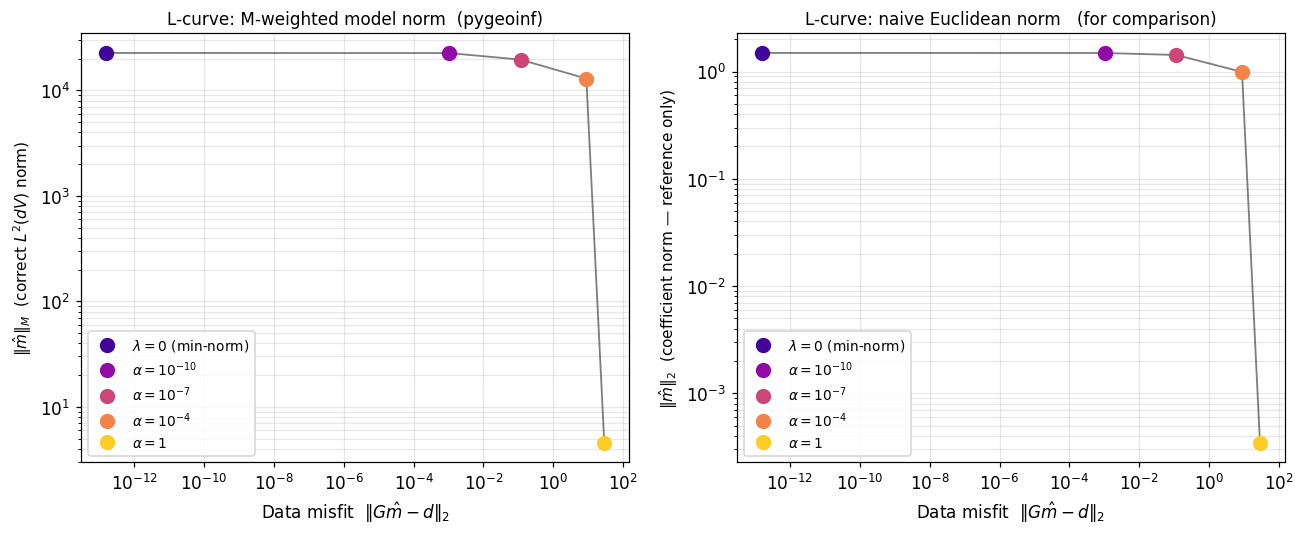

In [16]:
# ── L-curve ───────────────────────────────────────────────────────────────
# Prepend the exact min-norm result (λ=0) as the leftmost point on the curve
all_points = [{'label': r'$\lambda=0$ (min-norm)',
               'misfit': float(np.linalg.norm(G_mat @ m_hat_0 - d_noisy)),
               'mnorm':  float(model_space.norm(m_hat_0)),
               'cnorm':  float(np.linalg.norm(m_hat_0))}] + inv_results

misfits    = [p['misfit'] for p in all_points]
mnorms     = [p['mnorm']  for p in all_points]
cnorms     = [p['cnorm']  for p in all_points]
pt_colors  = plt.cm.plasma(np.linspace(0.1, 0.9, len(all_points)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, norms, ylabel, title in zip(
    axes,
    [mnorms, cnorms],
    [r'$\|\hat{m}\|_M$  (correct $L^2(dV)$ norm)',
     r'$\|\hat{m}\|_2$  (coefficient norm — reference only)'],
    ['L-curve: M-weighted model norm  (pygeoinf)',
     'L-curve: naive Euclidean norm   (for comparison)'],
):
    ax.loglog(misfits, norms, 'k-', lw=1.2, alpha=0.5)
    for pt, col in zip(all_points, pt_colors):
        norm_val = pt['mnorm'] if 'M' in ylabel else pt['cnorm']
        ax.loglog(pt['misfit'], norm_val, 'o', color=col, markersize=9,
                  label=pt['label'], zorder=5)
    ax.set_xlabel(r'Data misfit  $\|G\hat{m} - d\|_2$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, framealpha=0.85)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


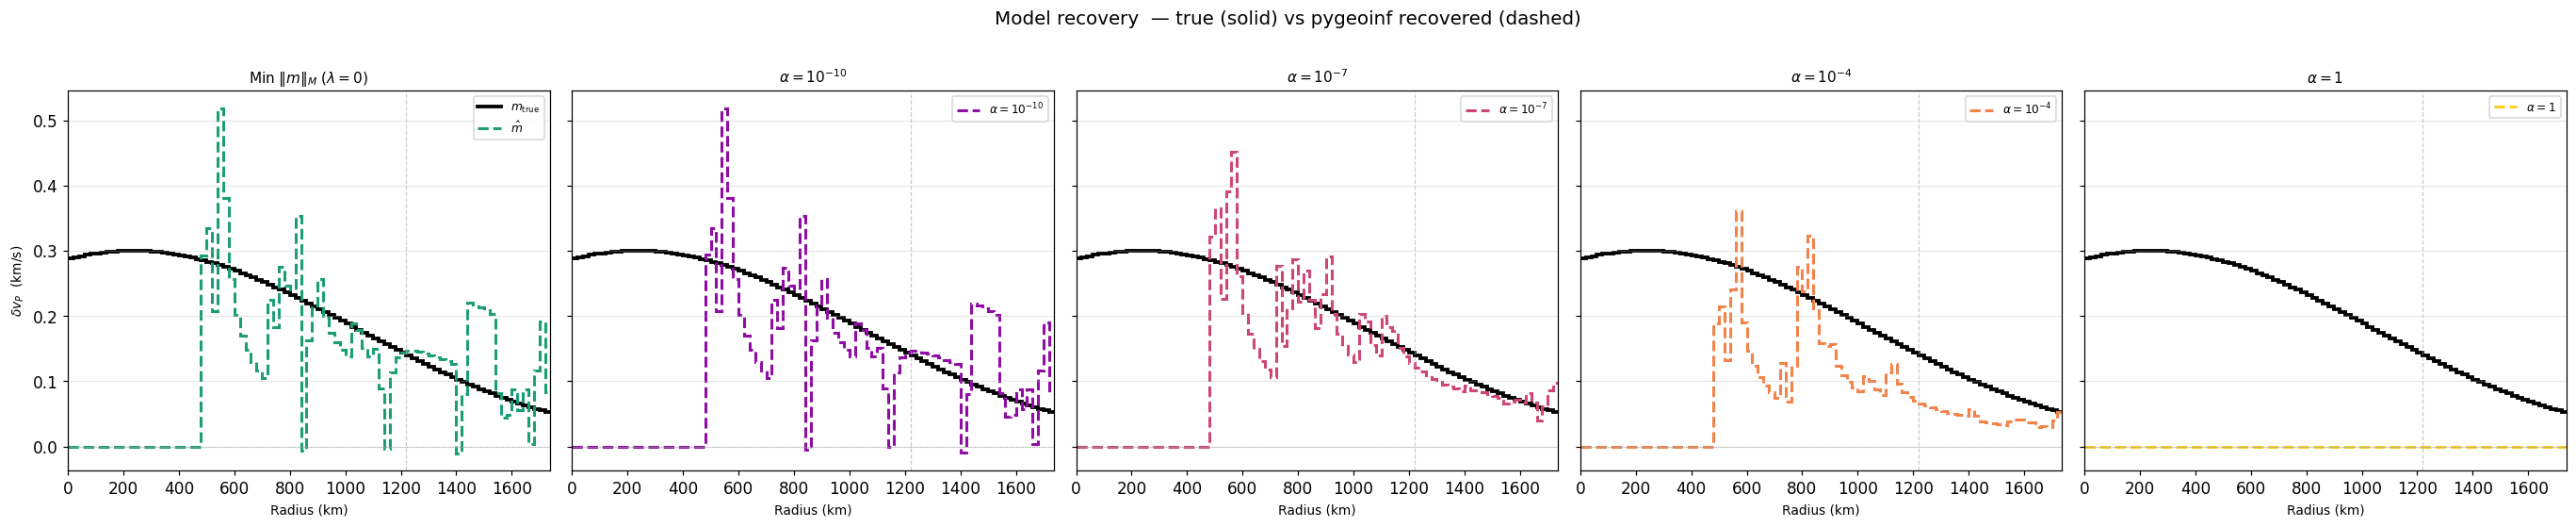

In [18]:
# ── Model recovery ─────────────────────────────────────────────────────────
n_panels   = 1 + len(inv_results)
res_colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(inv_results)))

fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), sharey=True)

# First panel: exact min M-norm
ax = axes[0]
ax.stairs(m_true, shell_radii, baseline=None, color='k', lw=2.5, label=r'$m_\mathrm{true}$')
ax.stairs(m_hat_0, shell_radii, baseline=None, color='#1b9e77', lw=2.0, ls='--', label=r'$\hat{m}$')
ax.set_title(r'Min $\|m\|_M$ ($\lambda=0$)', fontsize=10)
ax.set_xlabel('Radius (km)', fontsize=9)
ax.set_ylabel(r'$\delta v_P$  (km/s)', fontsize=9)
ax.legend(fontsize=8)
ax.axhline(0, color='0.6', lw=0.6, ls=':')
ax.grid(True, axis='y', alpha=0.3)
for r_disc in [3480.0, 1220.0]:
    ax.axvline(r_disc, color='#aaa', lw=0.8, ls='--', alpha=0.6)
ax.set_xlim(0, model.radius)

# Remaining panels: Tikhonov
for ax, res, col in zip(axes[1:], inv_results, res_colors):
    ax.stairs(m_true, shell_radii, baseline=None, color='k', lw=2.5)
    ax.stairs(res['m_hat'], shell_radii, baseline=None, color=col, lw=2.0, ls='--',
              label=res['label'])
    ax.set_title(res['label'], fontsize=10)
    ax.set_xlabel('Radius (km)', fontsize=9)
    ax.axhline(0, color='0.6', lw=0.6, ls=':')
    ax.grid(True, axis='y', alpha=0.3)
    for r_disc in [3480.0, 1220.0]:
        ax.axvline(r_disc, color='#aaa', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlim(0, model.radius)
    ax.legend(fontsize=8)

fig.suptitle('Model recovery  — true (solid) vs pygeoinf recovered (dashed)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 11 · Verify: pygeoinf == Manual Formula

Confirm that pygeoinf's `LinearMinimumNormInversion` gives the same answer as
our hand-rolled `min_norm_M` from Demo 07.

In [19]:
def min_norm_M_manual(G, d, M_inv_diag, lam=0.0):
    """Demo-07 hand-rolled min-norm: m̂ = M⁻¹Gᵀ(GM⁻¹Gᵀ + λI)⁻¹ d"""
    GMinvGt = (G * M_inv_diag[np.newaxis, :]) @ G.T
    A       = GMinvGt + lam * np.eye(GMinvGt.shape[0])
    alpha   = np.linalg.solve(A, d)
    return M_inv_diag * (G.T @ alpha)

m_hat_manual = min_norm_M_manual(G_mat, d_noisy, M_inv_diag, lam=0.0)

print('=== Comparison: pygeoinf vs manual (λ=0) ===')
print(f'  ||m̂_pg - m̂_manual||₂  = {np.linalg.norm(m_hat_0 - m_hat_manual):.2e}  ← should be ~0')
print(f'  ||G m̂_pg - d||₂       = {np.linalg.norm(G_mat @ m_hat_0 - d_noisy):.2e}')
print(f'  ||G m̂_manual - d||₂   = {np.linalg.norm(G_mat @ m_hat_manual - d_noisy):.2e}')

=== Comparison: pygeoinf vs manual (λ=0) ===
  ||m̂_pg - m̂_manual||₂  = 1.90e-13  ← should be ~0
  ||G m̂_pg - d||₂       = 1.54e-13
  ||G m̂_manual - d||₂   = 6.36e-14


## 12 · G Matrix Visualisation and SVD

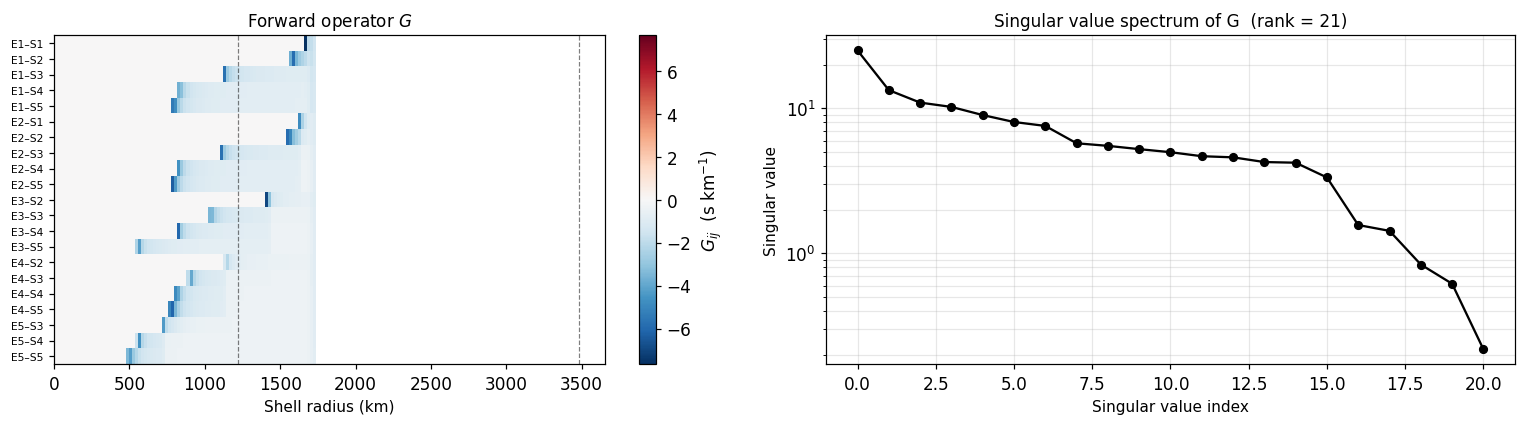

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
im = ax.imshow(G_mat, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(G_mat).max(), vmax=np.abs(G_mat).max(),
               extent=[shell_radii[0], shell_radii[-1], n_obs - 0.5, -0.5])
plt.colorbar(im, ax=ax, label=r'$G_{ij}$  (s km$^{-1}$)')
ax.set_yticks(range(n_obs))
ax.set_yticklabels(ray_labels, fontsize=7)
ax.set_xlabel('Shell radius (km)', fontsize=10)
ax.set_title(r'Forward operator $G$', fontsize=11)
for r_disc in [3480.0, 1220.0]:
    ax.axvline(r_disc, color='k', lw=0.8, ls='--', alpha=0.5)

ax = axes[1]
ax.semilogy(S_vals, 'ko-', markersize=5)
ax.set_xlabel('Singular value index', fontsize=10)
ax.set_ylabel('Singular value', fontsize=10)
ax.set_title(f'Singular value spectrum of G  (rank = {rank_G})', fontsize=11)
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Step | What was done |
|------|---------------|
| **Mesh** | M1 model, spherical, dr = 20 km |
| **Geometry** | 5 events × 5 stations → 25 P-wave arrivals |
| **Kernels** | $\tilde{K}_{ij} = -L_{ij}/v_j^2$, stacked into $G \in \mathbb{R}^{25 \times N}$ |
| **Model space** | `MassWeightedHilbertSpace`($M = \mathrm{diag}(V_j)$), inner product $u^T M v$ |
| **Data space** | `EuclideanSpace`($n_\mathrm{obs}$), standard dot product |
| **Operator** | `LinearOperator.from_matrix(model_space, data_space, G_mat, galerkin=False)` |
| **Adjoint** | $G^* = M^{-1}G^T$ — derived automatically by pygeoinf from the Riesz map |
| **Data error** | `GaussianMeasure.from_standard_deviation(data_space, σ)` |
| **Min-norm** | `LinearMinimumNormInversion` → $\hat{m} = G^*(GG^*)^{-1}d$ |
| **Tikhonov** | `LinearLeastSquaresInversion(damping)` → $\hat{m} = (G^T C_e^{-1} G + \alpha^2 M)^{-1} G^T C_e^{-1} d$ |
| **L-curve** | Trade-off between $\|G\hat{m}-d\|_2$ and $\|\hat{m}\|_M$ |

**Key takeaways**

- `MassWeightedHilbertSpace` encodes the $L^2(dV)$ geometry of the indicator-function
  basis. **No manual adjoint coding is needed**: pygeoinf derives $G^* = M^{-1}G^T$
  from the `to_dual` / `from_dual` Riesz maps of the space.
- The standard matrix $\tilde K$ is the correct **non-Galerkin** representation here
  because the data space is Euclidean. Use `galerkin=True` only when the matrix rows
  were assembled as dual-space objects (common when the codomain is also weighted).
- Tikhonov damping with the M-weighted forward problem automatically applies
  $\alpha^2 M$ (not $\alpha^2 I$), penalising the physically correct $L^2(dV)$ norm.
- Shell volumes span a **large range** ($\sim 10^3\times$), so the choice of inner
  product makes a material difference to the inversion result.